In [1]:
!pip install kaggle tensorflow scikit-learn matplotlib seaborn pandas numpy Pillow tqdm psutil -q
print('OK')


OK


In [2]:
import os,math,random,json,warnings,zipfile,shutil,time,tracemalloc,psutil
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from PIL import Image; from tqdm import tqdm
from collections import defaultdict; from itertools import cycle
from matplotlib.patches import Patch
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import Model, backend as K
from tensorflow.keras.layers import (
    Input,Conv2D,DepthwiseConv2D,SeparableConv2D,MaxPooling2D,AveragePooling2D,
    GlobalAveragePooling2D,GlobalMaxPooling2D,BatchNormalization,
    Flatten,Dense,Dropout,Add,Multiply,Concatenate,Reshape,Layer,
    Activation,Lambda,LayerNormalization
)
from tensorflow.keras.callbacks import LearningRateScheduler,EarlyStopping,ModelCheckpoint,ReduceLROnPlateau
from tensorflow.keras.losses import CategoricalFocalCrossentropy
from sklearn.model_selection import train_test_split,StratifiedKFold
from sklearn.metrics import (classification_report,confusion_matrix,
    accuracy_score,precision_score,recall_score,f1_score,roc_curve,auc)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

gpus = tf.config.list_physical_devices('GPU')
for g in gpus: tf.config.experimental.set_memory_growth(g,True)
print(f'TF {tf.__version__} | GPUs: {len(gpus)}')


2026-04-26 14:54:27.706463: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777215268.040076      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777215268.135416      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777215268.965599      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777215268.965639      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777215268.965642      55 computation_placer.cc:177] computation placer alr

TF 2.19.0 | GPUs: 2


In [3]:
NOTEBOOK_ID = "NB_A_Hybrid_SE_GAP"
NOTE        = "Inception(Add)+Skip(Concat)+SE-Attention+GAP — fixes 59M param problem"
SEED=42; IMG_SIZE=(256,256); IMG_SHAPE=(256,256,3)
BATCH_SIZE=64; INITIAL_LR=1e-3; EPOCHS=60; DROPOUT_RATE=0.4
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

TARGET_CLASSES=['Cotton_Aphids', 'Cotton_Army_worm', 'Cotton_Bacterial_Blight', 'Cotton_Healthy', 'Cotton_Powdery_mildew', 'Cotton_Target_Spot', 'Wheat_Brown_rust', 'Wheat_Healthy', 'Wheat_Yellow_rust', 'Potato_Early_blight', 'Potato_Late_blight', 'Potato_Healthy', 'Bell_Pepper_Bacterial_spot', 'Bell_Pepper_Healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites', 'Tomato_Target_spot', 'Tomato_Yellowleaf_curl_virus', 'Tomato_Mosaic_virus', 'Tomato_Healthy']
NUM_CLASSES=len(TARGET_CLASSES)
CLASS_TO_IDX={c:i for i,c in enumerate(TARGET_CLASSES)}
IDX_TO_CLASS={i:c for i,c in enumerate(TARGET_CLASSES)}
TARGET_COUNTS={'Cotton_Aphids': 800, 'Cotton_Army_worm': 800, 'Cotton_Bacterial_Blight': 800, 'Cotton_Healthy': 800, 'Cotton_Powdery_mildew': 800, 'Cotton_Target_Spot': 788, 'Wheat_Brown_rust': 902, 'Wheat_Healthy': 1116, 'Wheat_Yellow_rust': 924, 'Potato_Early_blight': 1000, 'Potato_Late_blight': 1000, 'Potato_Healthy': 152, 'Bell_Pepper_Bacterial_spot': 997, 'Bell_Pepper_Healthy': 1478, 'Tomato_Bacterial_spot': 2127, 'Tomato_Early_blight': 1000, 'Tomato_Late_blight': 1909, 'Tomato_Leaf_mold': 952, 'Tomato_Septoria_leaf_spot': 1771, 'Tomato_Spider_mites': 1676, 'Tomato_Target_spot': 1404, 'Tomato_Yellowleaf_curl_virus': 3209, 'Tomato_Mosaic_virus': 373, 'Tomato_Healthy': 1591}
KAGGLE_DATASETS=[('mohitsingh1804/plantvillage', 'plantvillage'), ('dhamur/cotton-plant-disease', 'cotton-plant-disease'), ('sinadunk23/behzad-safari-jalal', 'behzad-safari-jalal')]
VALID_EXTS={'.jpg','.jpeg','.png','.bmp','.tif','.tiff'}

BASE_DIR=os.path.join(os.path.expanduser('~'),'plant_project',NOTEBOOK_ID)
RAW_DIR =os.path.join(os.path.expanduser('~'),'plant_project','raw')
UNIFIED_DIR=os.path.join(BASE_DIR,'unified')
CKPT_DIR=os.path.join(BASE_DIR,'checkpoints')
LOG_DIR =os.path.join(BASE_DIR,'logs')
for d in [BASE_DIR,RAW_DIR,UNIFIED_DIR,CKPT_DIR,LOG_DIR]: os.makedirs(d,exist_ok=True)

def get_images(folder):
    if not os.path.isdir(folder): return []
    return [os.path.join(folder,f) for f in os.listdir(folder)
            if os.path.splitext(f)[1].lower() in VALID_EXTS]

print(f'{NOTEBOOK_ID} | {NOTE}'); print(f'Classes: {NUM_CLASSES} | Base: {BASE_DIR}')


NB_A_Hybrid_SE_GAP | Inception(Add)+Skip(Concat)+SE-Attention+GAP — fixes 59M param problem
Classes: 24 | Base: /root/plant_project/NB_A_Hybrid_SE_GAP


In [4]:
KAGGLE_USERNAME="jyotiradityachillal"; KAGGLE_KEY="KGAT_bba51b5487bd42a6dc26ac9524d520f9"
import json as _j
kd=os.path.expanduser("~/.kaggle"); os.makedirs(kd,exist_ok=True)
with open(os.path.join(kd,"kaggle.json"),"w") as f: _j.dump({"username":KAGGLE_USERNAME,"key":KAGGLE_KEY},f)
os.chmod(os.path.join(kd,"kaggle.json"),0o600)
os.environ["KAGGLE_USERNAME"]=KAGGLE_USERNAME; os.environ["KAGGLE_KEY"]=KAGGLE_KEY
print("Kaggle credentials set.")


Kaggle credentials set.


In [5]:
orig=os.getcwd(); os.chdir(RAW_DIR)
for ds_slug,folder_name in KAGGLE_DATASETS:
    tf2=os.path.join(RAW_DIR,folder_name); zf=os.path.join(RAW_DIR,folder_name+'.zip')
    if os.path.isdir(tf2) and os.listdir(tf2): print(f'  Ready: {folder_name}/'); continue
    if not os.path.isfile(zf): os.system(f'kaggle datasets download -d {ds_slug} --quiet')
    import zipfile as _zf
    with _zf.ZipFile(zf,'r') as z: z.extractall(tf2)
    print(f'  Extracted: {folder_name}')
os.chdir(orig); print('Done.')


Dataset URL: https://www.kaggle.com/datasets/mohitsingh1804/plantvillage
License(s): GPL-2.0
  Extracted: plantvillage
Dataset URL: https://www.kaggle.com/datasets/dhamur/cotton-plant-disease
License(s): ODbL-1.0
  Extracted: cotton-plant-disease
Dataset URL: https://www.kaggle.com/datasets/sinadunk23/behzad-safari-jalal
License(s): unknown
  Extracted: behzad-safari-jalal
Done.


In [6]:
FOLDER_MAP={
    'aphids':'Cotton_Aphids','aphid':'Cotton_Aphids',
    'army worm':'Cotton_Army_worm','army_worm':'Cotton_Army_worm','armyworm':'Cotton_Army_worm',
    'bacterial blight':'Cotton_Bacterial_Blight','bacterial_blight':'Cotton_Bacterial_Blight',
    'powdery mildew':'Cotton_Powdery_mildew','powdery_mildew':'Cotton_Powdery_mildew','powderymildew':'Cotton_Powdery_mildew',
    'target spot':'Cotton_Target_Spot','target_spot':'Cotton_Target_Spot',
    'pepper,_bell___bacterial_spot':'Bell_Pepper_Bacterial_spot','pepper___bacterial_spot':'Bell_Pepper_Bacterial_spot','bell_pepper___bacterial_spot':'Bell_Pepper_Bacterial_spot',
    'pepper,_bell___healthy':'Bell_Pepper_Healthy','pepper___healthy':'Bell_Pepper_Healthy','bell_pepper___healthy':'Bell_Pepper_Healthy',
    'potato___early_blight':'Potato_Early_blight','potato___late_blight':'Potato_Late_blight','potato___healthy':'Potato_Healthy',
    'tomato___bacterial_spot':'Tomato_Bacterial_spot','tomato___early_blight':'Tomato_Early_blight','tomato___late_blight':'Tomato_Late_blight',
    'tomato___leaf_mold':'Tomato_Leaf_mold','tomato___septoria_leaf_spot':'Tomato_Septoria_leaf_spot',
    'tomato___spider_mites two-spotted_spider_mite':'Tomato_Spider_mites','tomato___spider_mites_two-spotted_spider_mite':'Tomato_Spider_mites','tomato___spider_mites':'Tomato_Spider_mites',
    'tomato___target_spot':'Tomato_Target_spot','tomato___tomato_yellow_leaf_curl_virus':'Tomato_Yellowleaf_curl_virus',
    'tomato___tomato_mosaic_virus':'Tomato_Mosaic_virus','tomato___healthy':'Tomato_Healthy',
    'brown rust':'Wheat_Brown_rust','brown_rust':'Wheat_Brown_rust','brownrust':'Wheat_Brown_rust',
    'yellow rust':'Wheat_Yellow_rust','yellow_rust':'Wheat_Yellow_rust','yellowrust':'Wheat_Yellow_rust',
}

HEALTHY_CTX = {
    'cotton'              : 'Cotton_Healthy',
    'wheat'               : 'Wheat_Healthy',
    'behzad'              : 'Wheat_Healthy',   # <-- catches behzad-safari-jalal path
    'potato'              : 'Potato_Healthy',
}
def resolve_class(p):
    name=os.path.basename(p).lower().strip()
    if name in FOLDER_MAP: return FOLDER_MAP[name]
    if name in ('healthy','normal','disease free'):
        fl=p.lower()
        for k,v in HEALTHY_CTX.items():
            if k in fl: return v
    return None

class_files=defaultdict(list)
for _,folder in KAGGLE_DATASETS:
    ds_root=os.path.join(RAW_DIR,folder)
    if not os.path.isdir(ds_root): continue
    for dp,_,fnames in os.walk(ds_root):
        imgs=[f for f in fnames if os.path.splitext(f)[1].lower() in VALID_EXTS]
        if not imgs: continue
        cls=resolve_class(dp)
        if cls and cls in TARGET_CLASSES: class_files[cls].extend([os.path.join(dp,f) for f in imgs])

print('Scan done:')
for cls in TARGET_CLASSES: print(f'  {cls:<40} {len(class_files[cls]):>5}')


Scan done:
  Cotton_Aphids                             4320
  Cotton_Army_worm                          4320
  Cotton_Bacterial_Blight                   4320
  Cotton_Healthy                            4320
  Cotton_Powdery_mildew                     4320
  Cotton_Target_Spot                        4271
  Wheat_Brown_rust                          1128
  Wheat_Healthy                             1395
  Wheat_Yellow_rust                         1156
  Potato_Early_blight                       1000
  Potato_Late_blight                        1000
  Potato_Healthy                             152
  Bell_Pepper_Bacterial_spot                 997
  Bell_Pepper_Healthy                       1478
  Tomato_Bacterial_spot                     2127
  Tomato_Early_blight                       1000
  Tomato_Late_blight                        1909
  Tomato_Leaf_mold                           952
  Tomato_Septoria_leaf_spot                 1771
  Tomato_Spider_mites                       1676
  Tomato_

In [7]:
random.seed(SEED); actual_counts={}
for cls in TARGET_CLASSES:
    cls_dir=os.path.join(UNIFIED_DIR,cls); os.makedirs(cls_dir,exist_ok=True)
    ex=get_images(cls_dir)
    if ex: actual_counts[cls]=len(ex); continue
    srcs=class_files[cls][:]
    random.shuffle(srcs); srcs=srcs[:TARGET_COUNTS.get(cls,999999)]
    for i,src in enumerate(srcs):
        ext=os.path.splitext(src)[1].lower() or '.jpg'
        dst=os.path.join(cls_dir,f'{i:05d}{ext}')
        if not os.path.exists(dst): shutil.copy2(src,dst)
    actual_counts[cls]=len(srcs)
total=sum(actual_counts.values())
print(f'Unified: {total:,} images | {NUM_CLASSES} classes')

all_paths,all_labels=[],[]
for cls in TARGET_CLASSES:
    imgs=get_images(os.path.join(UNIFIED_DIR,cls))
    all_paths.extend(imgs); all_labels.extend([CLASS_TO_IDX[cls]]*len(imgs))
all_paths=np.array(all_paths); all_labels=np.array(all_labels,dtype=np.int32)

# ── Class weights to fix Wheat_Healthy (0% sensitivity) ──────────────────
cw=compute_class_weight('balanced',classes=np.unique(all_labels),y=all_labels)
class_weights={i:w for i,w in enumerate(cw)}
print('Class weights computed (fixes imbalanced classes):')
for i,cls in enumerate(TARGET_CLASSES):
    if class_weights[i]>2: print(f'  {cls}: weight={class_weights[i]:.2f}  <-- boosted')


Unified: 28,369 images | 24 classes
Class weights computed (fixes imbalanced classes):
  Potato_Healthy: weight=7.78  <-- boosted
  Tomato_Mosaic_virus: weight=3.17  <-- boosted


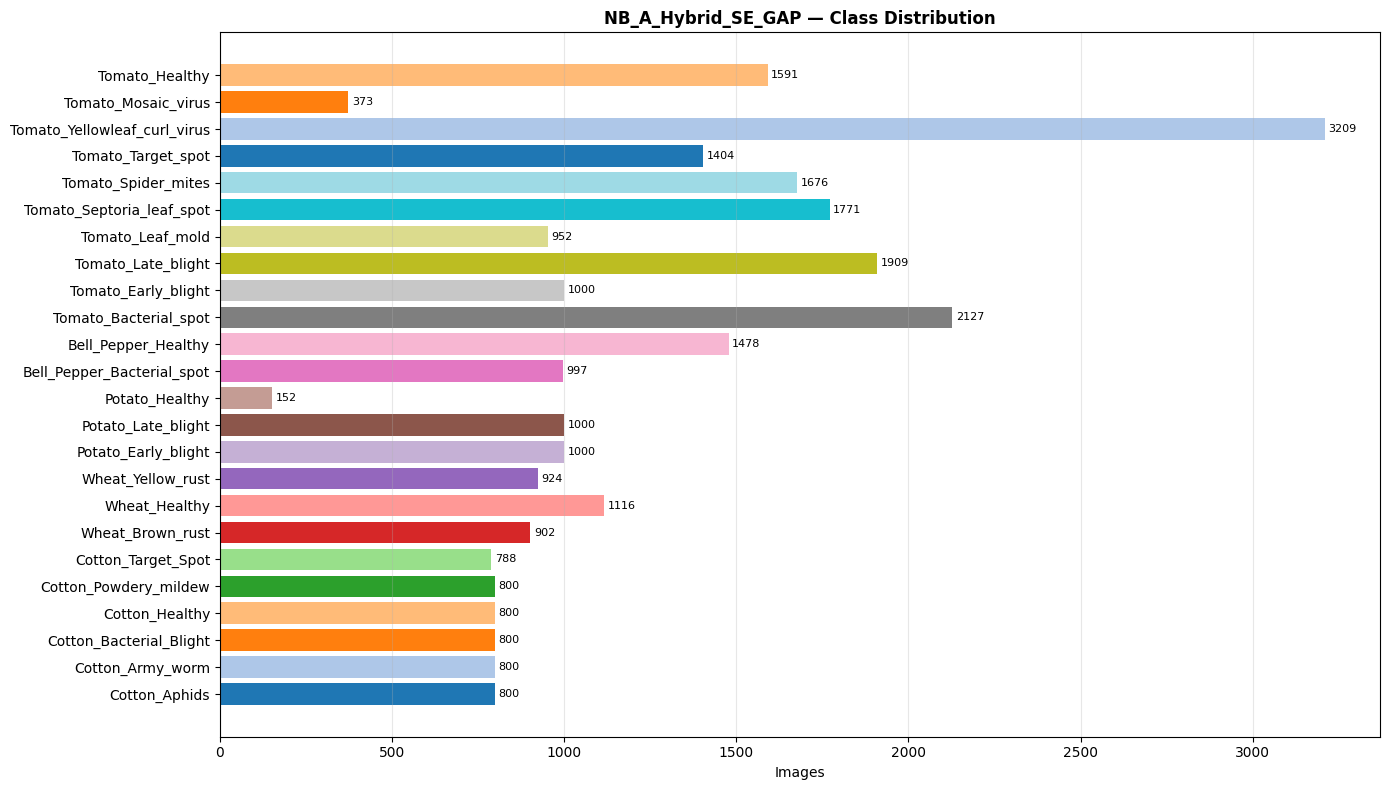

Total: 28,369


In [8]:
counts=[len(get_images(os.path.join(UNIFIED_DIR,c))) for c in TARGET_CLASSES]
fig,ax=plt.subplots(figsize=(14,8))
colors=plt.cm.tab20.colors
bars=ax.barh(TARGET_CLASSES,counts,color=[colors[i%20] for i in range(NUM_CLASSES)])
ax.set_xlabel('Images'); ax.set_title(f'{NOTEBOOK_ID} — Class Distribution',fontweight='bold')
ax.grid(True,axis='x',alpha=0.3)
for bar,v in zip(bars,counts): ax.text(bar.get_width()+10,bar.get_y()+bar.get_height()/2,str(v),va='center',fontsize=8)
plt.tight_layout(); plt.savefig(os.path.join(LOG_DIR,'eda.png'),dpi=120,bbox_inches='tight'); plt.show()
print(f'Total: {sum(counts):,}')


In [9]:
import tensorflow as tf

X_tr,X_tmp,y_tr,y_tmp=train_test_split(all_paths,all_labels,test_size=0.30,random_state=SEED,stratify=all_labels)
X_val,X_te,y_val,y_te=train_test_split(X_tmp,y_tmp,test_size=0.50,random_state=SEED,stratify=y_tmp)
print(f'Train {len(X_tr):,}  Val {len(X_val):,}  Test {len(X_te):,}')

AUTOTUNE=tf.data.AUTOTUNE
def load_img(path,label):
    raw=tf.io.read_file(path)
    img=tf.image.decode_image(raw,channels=3,expand_animations=False)
    img=tf.image.resize(img,IMG_SIZE)
    return tf.cast(img,tf.float32)/255.0, label

def augment(img,label):
    img=tf.image.random_flip_left_right(img); img=tf.image.random_flip_up_down(img)
    img=tf.image.random_brightness(img,0.2); img=tf.image.random_contrast(img,0.8,1.2)
    img=tf.image.random_saturation(img,0.8,1.2); img=tf.image.random_hue(img,0.08)
    img=tf.image.random_jpeg_quality(img,70,100)
    return tf.clip_by_value(img,0.0,1.0),label

def make_ds(paths,labels,training=False):
    ds=tf.data.Dataset.from_tensor_slices((paths,labels))
    if training: ds=ds.shuffle(min(len(paths),10000),seed=SEED)
    ds=ds.map(load_img,num_parallel_calls=AUTOTUNE)
    if training: ds=ds.map(augment,num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds=make_ds(X_tr,y_tr,training=True)
val_ds=make_ds(X_val,y_val); test_ds=make_ds(X_te,y_te)
print('Pipelines ready (augmentation includes JPEG quality noise).')


Train 19,858  Val 4,255  Test 4,256


I0000 00:00:1777215497.823236      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777215497.829311      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Pipelines ready (augmentation includes JPEG quality noise).


In [10]:
class CosineWarmupScheduler(LearningRateScheduler):
    """Cosine annealing with linear warmup for first 5 epochs."""
    def __init__(self,initial_lr,total_epochs,warmup_epochs=5):
        self.initial_lr=initial_lr; self.total_epochs=total_epochs; self.warmup=warmup_epochs
        super().__init__(self._sched,verbose=0)
    def _sched(self,epoch,lr):
        if epoch<self.warmup: return self.initial_lr*(epoch+1)/self.warmup
        t=epoch-self.warmup; T=self.total_epochs-self.warmup
        return 0.5*self.initial_lr*(1+math.cos(math.pi*t/T))
    def get_config(self):
        cfg=super().get_config(); cfg.update({'initial_lr':self.initial_lr,'total_epochs':self.total_epochs,'warmup_epochs':self.warmup}); return cfg

print('CosineWarmup scheduler defined (warmup 5 epochs).')


CosineWarmup scheduler defined (warmup 5 epochs).


In [11]:
class Inception_SE(Layer):
    def __init__(self, num_filters, se_ratio=8, activation='relu', padding='same', **kwargs):
        super().__init__(**kwargs)
        self.num_filters=num_filters; self.se_ratio=se_ratio
        self.activation=activation; self.padding=padding
        # Inception branches
        self.conv3=Conv2D(num_filters,(3,3),activation=activation,padding=padding)
        self.conv5=Conv2D(num_filters,(5,5),activation=activation,padding=padding)
        self.conv7=Conv2D(num_filters,(7,7),activation=activation,padding=padding)
        # SE block layers — must be in __init__, not call()
        self.se_gap  = GlobalAveragePooling2D()
        self.se_fc1  = Dense(max(num_filters//se_ratio,1), activation='relu')
        self.se_fc2  = Dense(num_filters, activation='sigmoid')
        self.se_rs   = Reshape((1,1,num_filters))
        self.se_mul  = Multiply()

    def call(self, x, training=False):
        out = Add()([self.conv3(x), self.conv5(x), self.conv7(x)])
        sq  = self.se_gap(out)
        sq  = self.se_fc1(sq)
        sq  = self.se_fc2(sq)
        sq  = self.se_rs(sq)
        return self.se_mul([out, sq])

    def get_config(self):
        cfg=super().get_config()
        cfg.update({'num_filters':self.num_filters,'se_ratio':self.se_ratio,
                    'activation':self.activation,'padding':self.padding})
        return cfg


class SkipConnection_SE(Layer):
    def __init__(self, num_filters, se_ratio=8, activation='relu', padding='same', **kwargs):
        super().__init__(**kwargs)
        self.num_filters=num_filters; self.se_ratio=se_ratio
        self.conv=Conv2D(num_filters,(7,7),activation=activation,padding=padding)
        self.bn=BatchNormalization()
        self.concat=Concatenate(axis=-1)
        # SE layers — channel count after concat = num_filters + input_channels
        # We don't know input_channels at __init__ time, so build lazily via build()
        self.se_fc1=None; self.se_fc2=None

    def build(self, input_shape):
        # input_shape is the shape of x going into call()
        concat_ch = self.num_filters + input_shape[-1]
        self.se_gap = GlobalAveragePooling2D()
        self.se_fc1 = Dense(max(concat_ch//self.se_ratio,1), activation='relu')
        self.se_fc2 = Dense(concat_ch, activation='sigmoid')
        self.se_rs  = Reshape((1,1,concat_ch))
        self.se_mul = Multiply()
        super().build(input_shape)

    def call(self, x, training=False):
        out = self.conv(x)
        out = self.bn(out, training=training)
        out = self.concat([out, x])
        sq  = self.se_gap(out)
        sq  = self.se_fc1(sq)
        sq  = self.se_fc2(sq)
        sq  = self.se_rs(sq)
        return self.se_mul([out, sq])

    def get_config(self):
        cfg=super().get_config()
        cfg.update({'num_filters':self.num_filters,'se_ratio':self.se_ratio})
        return cfg

print('SE-attention layers defined.')

SE-attention layers defined.


In [12]:
# KEY CHANGES vs original:
#  1. SE attention after every Inception + Skip block
#  2. GlobalAveragePooling2D instead of Flatten (59M → ~2M params)
#  3. Smaller FC head with stronger dropout
#  4. 60 epochs + warmup scheduler
def build_model(dropout_override=None):
    dr = dropout_override if dropout_override is not None else DROPOUT_RATE
    inp=Input(shape=IMG_SHAPE)
    x=Inception_SE(16,name='inc_se_1')(inp)
    x=BatchNormalization()(x); x=MaxPooling2D((2,2))(x)
    x=Inception_SE(32,name='inc_se_2')(x)
    x=BatchNormalization()(x); x=MaxPooling2D((2,2))(x)
    x=SkipConnection_SE(64,name='skip_se_1')(x); x=MaxPooling2D((2,2))(x)
    x=SkipConnection_SE(128,name='skip_se_2')(x); x=MaxPooling2D((2,2))(x)
    x=GlobalAveragePooling2D()(x)          # replaces Flatten: 57344→128 inputs to Dense
    x=Dense(512,activation='relu')(x)
    x=Dropout(0.4)(x)
    x=Dense(128,activation='relu')(x)
    x=Dropout(0.3)(x)
    out=Dense(NUM_CLASSES,activation='softmax')(x)
    return Model(inp,out,name='Hybrid_SE_GAP')
model=build_model(); model.summary()
print(f'Params: {model.count_params():,}  (original was 59.7M)')


Model: "Hybrid_SE_GAP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inc_se_1 (Inception_SE)         │ (None, 256, 256, 16)   │         4,114 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inc_se_2 (Inception_SE)         │ (None, 128, 128, 32)   │        42,884 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ skip_se_1 (SkipConnection_SE)   │ (None, 64, 64, 96)     │       103,084 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ skip_se_2 (SkipConnection_SE)   │ (None, 32, 32, 224)    │       615,548 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 224)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 224)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       115,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 949,782 (3.62 MB)

 Trainable params: 949,302 (3.62 MB)

 Non-trainable params: 480 (1.88 KB)

Params: 949,782  (original was 59.7M)


Grid search subset: 7,943 samples  (40% of train set)
Grid: 3 LRs × 3 dropouts = 9 combos × 3 folds

[1/9] lr=0.001  dropout=0.3


I0000 00:00:1777215513.161783     143 service.cc:152] XLA service 0x7a9620002ea0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777215513.161833     143 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777215513.161839     143 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777215514.707157     143 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-26 14:58:45.190750: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-26 14:58:45.345584: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-26 14:58:47.479609: E external/local_xl

   fold 1: val_acc=0.7338
   fold 2: val_acc=0.7334


2026-04-26 15:13:21.051356: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-26 15:13:21.206076: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-26 15:13:23.168497: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-26 15:13:23.464867: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-26 15:13:23.704549: E external/local_xla/xla/service

   fold 3: val_acc=0.7295
   → mean=0.7322  std=0.0019

[2/9] lr=0.001  dropout=0.4
   fold 1: val_acc=0.7066
   fold 2: val_acc=0.7421
   fold 3: val_acc=0.7091
   → mean=0.7192  std=0.0162

[3/9] lr=0.001  dropout=0.5
   fold 1: val_acc=0.7711
   fold 2: val_acc=0.7364
   fold 3: val_acc=0.7167
   → mean=0.7414  std=0.0225

[4/9] lr=0.0005  dropout=0.3
   fold 1: val_acc=0.7693
   fold 2: val_acc=0.7289
   fold 3: val_acc=0.7333
   → mean=0.7438  std=0.0181

[5/9] lr=0.0005  dropout=0.4
   fold 1: val_acc=0.7451
   fold 2: val_acc=0.7402
   fold 3: val_acc=0.6808
   → mean=0.7220  std=0.0292

[6/9] lr=0.0005  dropout=0.5
   fold 1: val_acc=0.7221
   fold 2: val_acc=0.7149
   fold 3: val_acc=0.7537
   → mean=0.7302  std=0.0169

[7/9] lr=0.0001  dropout=0.3
   fold 1: val_acc=0.6654
   fold 2: val_acc=0.7255
   fold 3: val_acc=0.7185
   → mean=0.7031  std=0.0268

[8/9] lr=0.0001  dropout=0.4
   fold 1: val_acc=0.7115
   fold 2: val_acc=0.7002
   fold 3: val_acc=0.7080
   → mean=0.7065 

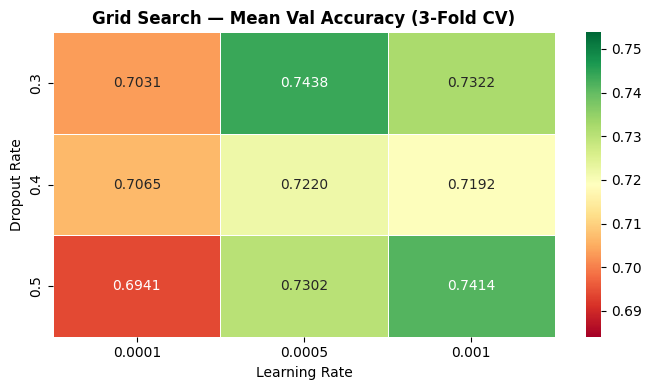

In [13]:
# ════════════════════════════════════════════════════════════════════════
# GRID SEARCH CROSS-VALIDATION
# Searches: learning_rate × dropout_rate (3×3 = 9 combinations, 3 folds)
# Runs on a stratified 40% subset to keep runtime manageable on GPU.
# Best params are automatically used in the main training cell below.
# ════════════════════════════════════════════════════════════════════════
from sklearn.model_selection import StratifiedKFold
from sklearn.utils import resample
import itertools, gc

# ── Hyperparameter grid ───────────────────────────────────────────────────
PARAM_GRID = {
    'learning_rate': [1e-3, 5e-4, 1e-4],
    'dropout_rate' : [0.3, 0.4, 0.5],
}
GS_EPOCHS    = 15          # lightweight epochs per fold during search
GS_FOLDS     = 3           # stratified k-folds
GS_SUBSET    = 0.40        # fraction of full train set used for search

# ── Sample a stratified subset ────────────────────────────────────────────
from sklearn.model_selection import train_test_split as _tts
X_gs, _, y_gs, _ = _tts(X_tr, y_tr, train_size=GS_SUBSET,
                          random_state=SEED, stratify=y_tr)
print(f'Grid search subset: {len(X_gs):,} samples  '
      f'({GS_SUBSET*100:.0f}% of train set)')
print(f'Grid: {len(PARAM_GRID["learning_rate"])} LRs × '
      f'{len(PARAM_GRID["dropout_rate"])} dropouts = '
      f'{len(PARAM_GRID["learning_rate"])*len(PARAM_GRID["dropout_rate"])} combos × '
      f'{GS_FOLDS} folds\n')

# ── Grid search loop ──────────────────────────────────────────────────────
gs_results = []
skf = StratifiedKFold(n_splits=GS_FOLDS, shuffle=True, random_state=SEED)
combos = list(itertools.product(PARAM_GRID['learning_rate'],
                                PARAM_GRID['dropout_rate']))

for combo_idx, (lr, dr) in enumerate(combos):
    fold_val_accs = []
    print(f'[{combo_idx+1}/{len(combos)}] lr={lr}  dropout={dr}')

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_gs, y_gs)):
        X_f_tr  = X_gs[tr_idx];  y_f_tr  = y_gs[tr_idx]
        X_f_val = X_gs[val_idx]; y_f_val = y_gs[val_idx]

        ds_tr  = make_ds(X_f_tr,  y_f_tr,  training=True)
        ds_val = make_ds(X_f_val, y_f_val, training=False)

        # Build a fresh model with current dropout
        m = build_model(dropout_override=dr)
        m.compile(optimizer=tf.keras.optimizers.Adam(lr),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

        h = m.fit(ds_tr, epochs=GS_EPOCHS,
                  validation_data=ds_val,
                  verbose=0,
                  callbacks=[
                      EarlyStopping(monitor='val_accuracy',
                                    patience=4,
                                    restore_best_weights=True,
                                    verbose=0)
                  ])

        best_val = max(h.history['val_accuracy'])
        fold_val_accs.append(best_val)
        print(f'   fold {fold+1}: val_acc={best_val:.4f}')

        del m, ds_tr, ds_val
        tf.keras.backend.clear_session()
        gc.collect()

    mean_acc = np.mean(fold_val_accs)
    std_acc  = np.std(fold_val_accs)
    gs_results.append({
        'learning_rate': lr,
        'dropout_rate' : dr,
        'mean_val_acc' : mean_acc,
        'std_val_acc'  : std_acc,
        'fold_accs'    : fold_val_accs,
    })
    print(f'   → mean={mean_acc:.4f}  std={std_acc:.4f}\n')

# ── Results table ─────────────────────────────────────────────────────────
gs_df = pd.DataFrame(gs_results).sort_values('mean_val_acc', ascending=False)
gs_df.to_csv(os.path.join(LOG_DIR, 'grid_search_results.csv'), index=False)

print('='*55)
print('GRID SEARCH RESULTS (sorted by mean val accuracy):')
print('='*55)
print(gs_df[['learning_rate','dropout_rate',
             'mean_val_acc','std_val_acc']].to_string(index=False))

best_row   = gs_df.iloc[0]
BEST_LR    = best_row['learning_rate']
BEST_DR    = best_row['dropout_rate']
print(f'\n✓ Best params:  lr={BEST_LR}  dropout={BEST_DR}')
print(f'  Best mean val_acc = {best_row["mean_val_acc"]:.4f} ± {best_row["std_val_acc"]:.4f}')
print(f'\nThese will be used automatically in the training cell below.')

# ── Plot grid search heatmap ──────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

pivot = gs_df.pivot(index='dropout_rate', columns='learning_rate', values='mean_val_acc')
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='RdYlGn',
            vmin=pivot.values.min()-0.01, vmax=pivot.values.max()+0.01,
            linewidths=0.5, linecolor='white', ax=ax)
ax.set_title('Grid Search — Mean Val Accuracy (3-Fold CV)', fontweight='bold')
ax.set_xlabel('Learning Rate'); ax.set_ylabel('Dropout Rate')
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, 'grid_search_heatmap.png'),
            dpi=130, bbox_inches='tight')
plt.show()

In [14]:
ckpt_path = os.path.join(CKPT_DIR, 'best.weights.h5')

# Use best params found by grid search (falls back to defaults if search skipped)
FINAL_LR = BEST_LR if 'BEST_LR' in dir() else INITIAL_LR
FINAL_DR = BEST_DR if 'BEST_DR' in dir() else DROPOUT_RATE

print(f'Training with  lr={FINAL_LR}  dropout={FINAL_DR}')

model = build_model(dropout_override=FINAL_DR)
model.compile(
    optimizer=tf.keras.optimizers.Adam(FINAL_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    CosineWarmupScheduler(FINAL_LR, EPOCHS, warmup_epochs=5),  # ← was INITIAL_LR, now FINAL_LR
    ModelCheckpoint(ckpt_path, monitor='val_accuracy', save_best_only=True,
                    save_weights_only=True, verbose=0),
    EarlyStopping(monitor='val_loss', patience=12,
                  restore_best_weights=True, verbose=1),
]

tracemalloc.start()
t0 = time.time()
history = model.fit(
    train_ds, epochs=EPOCHS,
    validation_data=val_ds,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)
train_time = time.time() - t0
_, peak_mem = tracemalloc.get_traced_memory()
tracemalloc.stop()
ram_used_mb = psutil.Process().memory_info().rss / 1e6

print(f'Done in {train_time/60:.1f} min  |  RAM: {ram_used_mb:.0f} MB')

Training with  lr=0.0005  dropout=0.3
Epoch 1/60
310/311 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 0.1551 - loss: 2.8677

2026-04-26 17:59:46.059634: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-26 17:59:46.205833: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-26 17:59:47.423681: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-26 17:59:47.703830: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-26 17:59:47.942770: E external/local_xla/xla/service

311/311 ━━━━━━━━━━━━━━━━━━━━ 138s 368ms/step - accuracy: 0.1556 - loss: 2.8659 - val_accuracy: 0.0905 - val_loss: 3.7912 - learning_rate: 1.0000e-04
Epoch 2/60
311/311 ━━━━━━━━━━━━━━━━━━━━ 89s 285ms/step - accuracy: 0.3647 - loss: 2.0123 - val_accuracy: 0.3640 - val_loss: 1.8817 - learning_rate: 2.0000e-04
Epoch 3/60
311/311 ━━━━━━━━━━━━━━━━━━━━ 89s 284ms/step - accuracy: 0.4836 - loss: 1.5869 - val_accuracy: 0.3974 - val_loss: 1.9002 - learning_rate: 3.0000e-04
Epoch 4/60
311/311 ━━━━━━━━━━━━━━━━━━━━ 89s 284ms/step - accuracy: 0.5457 - loss: 1.3435 - val_accuracy: 0.4392 - val_loss: 1.7213 - learning_rate: 4.0000e-04
Epoch 5/60
311/311 ━━━━━━━━━━━━━━━━━━━━ 88s 283ms/step - accuracy: 0.5892 - loss: 1.2056 - val_accuracy: 0.6552 - val_loss: 1.0272 - learning_rate: 5.0000e-04
Epoch 6/60
311/311 ━━━━━━━━━━━━━━━━━━━━ 88s 282ms/step - accuracy: 0.6572 - loss: 1.0177 - val_accuracy: 0.6418 - val_loss: 1.0684 - learning_rate: 5.0000e-04
Epoch 7/60
311/311 ━━━━━━━━━━━━━━━━━━━━ 88s 284ms/step -

In [15]:
ckpt_path=os.path.join(CKPT_DIR,'best.weights.h5')
if os.path.exists(ckpt_path): model.load_weights(ckpt_path)
y_prob=model.predict(test_ds,verbose=1)
y_pred=np.argmax(y_prob,axis=1)
y_true=np.concatenate([y for _,y in test_ds])[:len(y_pred)]

acc=accuracy_score(y_true,y_pred)
prec=precision_score(y_true,y_pred,average='weighted',zero_division=0)
rec=recall_score(y_true,y_pred,average='weighted',zero_division=0)
f1=f1_score(y_true,y_pred,average='weighted',zero_division=0)
report_dict=classification_report(y_true,y_pred,target_names=TARGET_CLASSES,output_dict=True,zero_division=0)
sensitivity={cls:report_dict[cls]['recall'] for cls in TARGET_CLASSES}
spec_list=[]
for i,cls in enumerate(TARGET_CLASSES):
    tp=np.sum((y_true==i)&(y_pred==i)); fp=np.sum((y_true!=i)&(y_pred==i))
    tn=np.sum((y_true!=i)&(y_pred!=i)); fn=np.sum((y_true==i)&(y_pred!=i))
    spec_list.append(tn/(tn+fp) if (tn+fp)>0 else 0)
mean_spec=np.mean(spec_list)

print('='*55); print(f'  {NOTEBOOK_ID}')
print('='*55)
print(f'  Accuracy    : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision   : {prec:.4f}')
print(f'  Recall      : {rec:.4f}')
print(f'  F1-Score    : {f1:.4f}')
print(f'  Specificity : {mean_spec:.4f}')
print(f'  Params      : {model.count_params():,}')
print(f'  Train time  : {train_time/60:.1f} min')
print('='*55)


67/67 ━━━━━━━━━━━━━━━━━━━━ 11s 149ms/step
  NB_A_Hybrid_SE_GAP
  Accuracy    : 0.9671  (96.71%)
  Precision   : 0.9675
  Recall      : 0.9671
  F1-Score    : 0.9671
  Specificity : 0.9986
  Params      : 949,782
  Train time  : 88.7 min


CSVs saved.


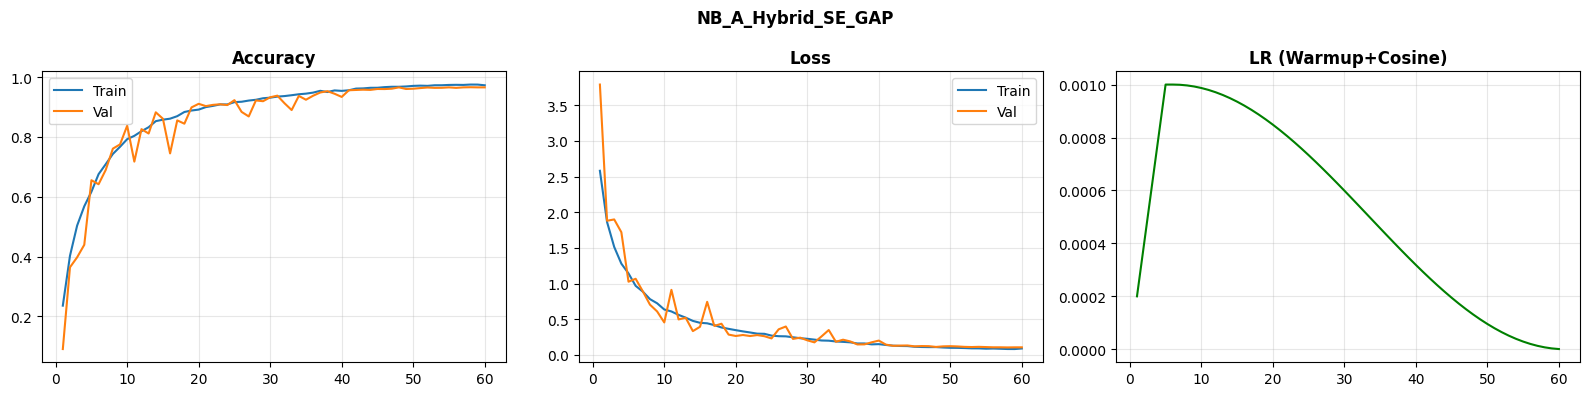

In [16]:
hist=history.history; hist_df=pd.DataFrame(hist)
hist_df['epoch']=range(1,len(hist_df)+1); hist_df['notebook']=NOTEBOOK_ID
hist_df['train_time_sec']=train_time; hist_df['total_params']=model.count_params()
hist_df.to_csv(os.path.join(LOG_DIR,'training_history.csv'),index=False)

metrics_df=pd.DataFrame([{'notebook':NOTEBOOK_ID,'accuracy':acc,'precision':prec,'recall':rec,
    'f1':f1,'specificity':mean_spec,'params':model.count_params(),
    'train_time_min':train_time/60,'num_classes':NUM_CLASSES,'best_val_acc':max(hist['val_accuracy'])}])
metrics_df.to_csv(os.path.join(LOG_DIR,'metrics_summary.csv'),index=False)

per_class_df=pd.DataFrame([{
    'class':cls,'sensitivity':sensitivity[cls],
    'precision':report_dict[cls]['precision'],'f1':report_dict[cls]['f1-score'],
    'specificity':spec_list[i]
} for i,cls in enumerate(TARGET_CLASSES)])
per_class_df.to_csv(os.path.join(LOG_DIR,'per_class_metrics.csv'),index=False)
print('CSVs saved.')

# Plot training curves
fig,axes=plt.subplots(1,3,figsize=(16,4))
n_ep=range(1,len(hist['loss'])+1)
axes[0].plot(n_ep,hist['accuracy'],label='Train'); axes[0].plot(n_ep,hist['val_accuracy'],label='Val')
axes[0].set_title('Accuracy',fontweight='bold'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(n_ep,hist['loss'],label='Train'); axes[1].plot(n_ep,hist['val_loss'],label='Val')
axes[1].set_title('Loss',fontweight='bold'); axes[1].legend(); axes[1].grid(alpha=0.3)
lrs=[CosineWarmupScheduler(INITIAL_LR,EPOCHS)._sched(e,0) for e in range(len(hist['loss']))]
axes[2].plot(n_ep,lrs,color='green'); axes[2].set_title('LR (Warmup+Cosine)',fontweight='bold'); axes[2].grid(alpha=0.3)
fig.suptitle(f'{NOTEBOOK_ID}',fontweight='bold'); plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR,'training_curves.png'),dpi=120,bbox_inches='tight'); plt.show()


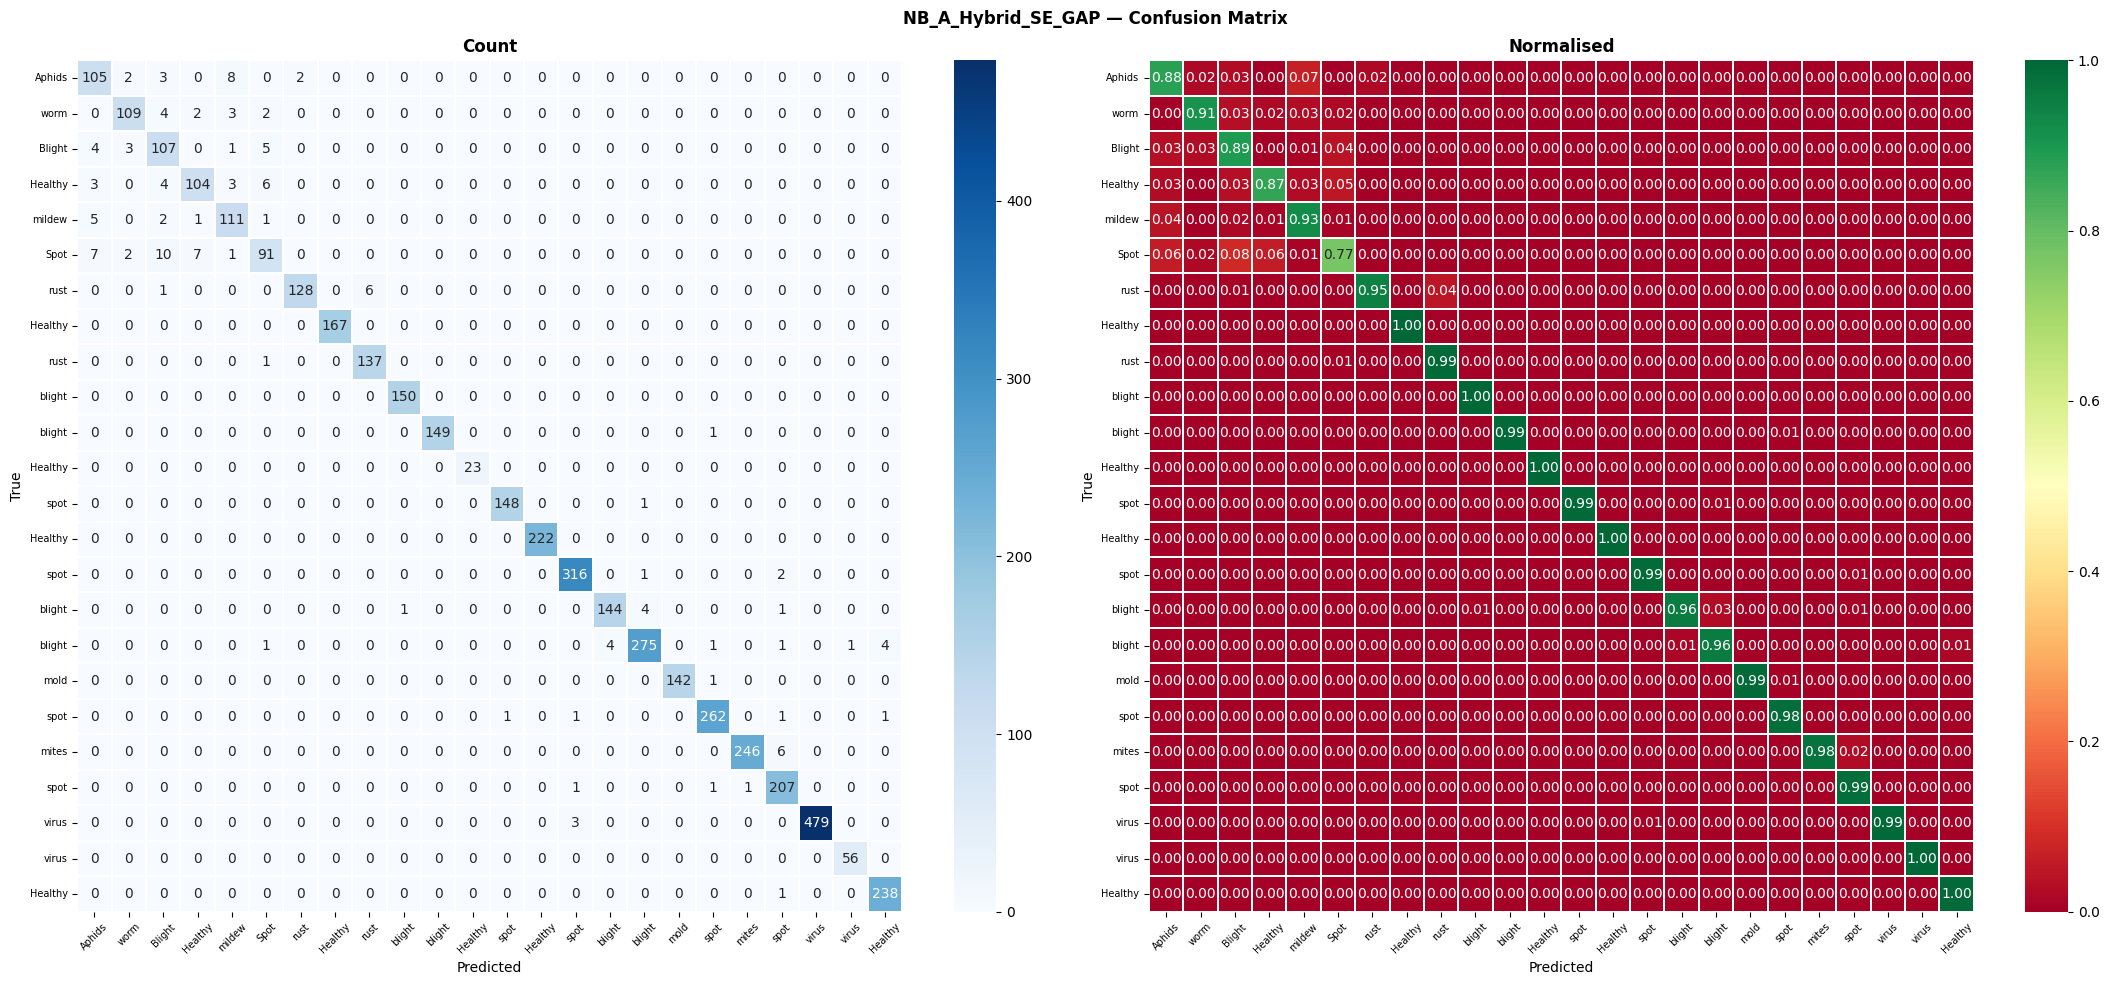

In [17]:
# Confusion matrix
cm=confusion_matrix(y_true,y_pred)
cm_norm=cm.astype(float)/cm.sum(axis=1,keepdims=True)
short=[c.split('_')[-1][:8] for c in TARGET_CLASSES]
fig,axes=plt.subplots(1,2,figsize=(22,10))
for ax,data,fmt,cmap,title in [(axes[0],cm,'d','Blues','Count'),(axes[1],cm_norm,'.2f','RdYlGn','Normalised')]:
    sns.heatmap(data,ax=ax,cmap=cmap,fmt=fmt,annot=True,xticklabels=short,yticklabels=short,
                linewidths=0.3,linecolor='white',**({'vmin':0,'vmax':1} if fmt=='.2f' else {}))
    ax.set_title(title,fontweight='bold'); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x',rotation=45,labelsize=7); ax.tick_params(axis='y',rotation=0,labelsize=7)
plt.suptitle(f'{NOTEBOOK_ID} — Confusion Matrix',fontweight='bold'); plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR,'confusion_matrix.png'),dpi=120,bbox_inches='tight'); plt.show()


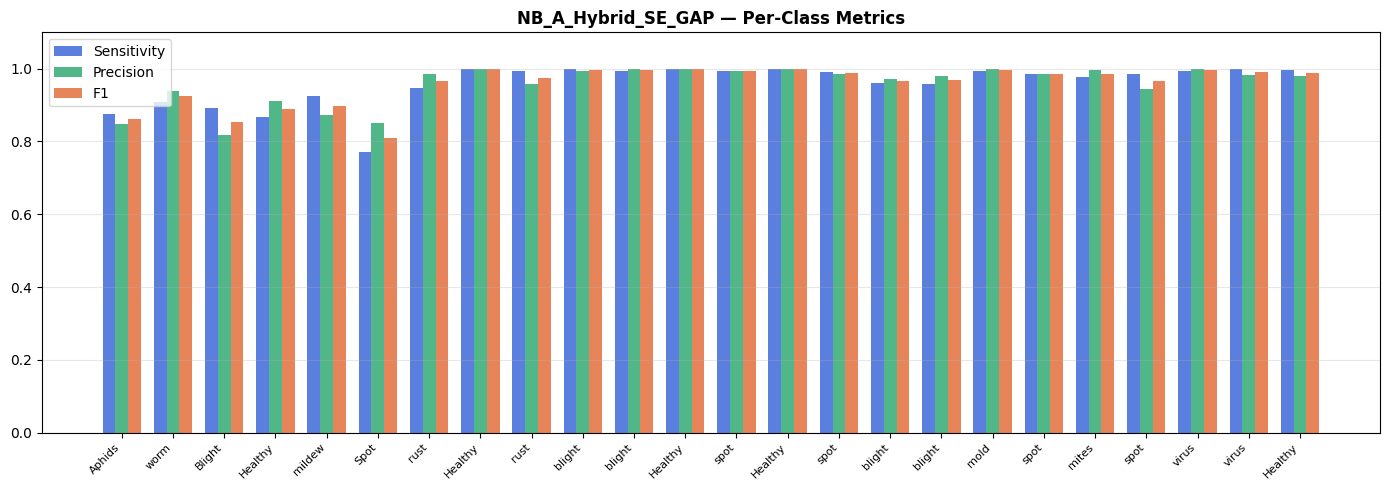

                              precision    recall  f1-score   support

               Cotton_Aphids     0.8468    0.8750    0.8607       120
            Cotton_Army_worm     0.9397    0.9083    0.9237       120
     Cotton_Bacterial_Blight     0.8168    0.8917    0.8526       120
              Cotton_Healthy     0.9123    0.8667    0.8889       120
       Cotton_Powdery_mildew     0.8740    0.9250    0.8988       120
          Cotton_Target_Spot     0.8505    0.7712    0.8089       118
            Wheat_Brown_rust     0.9846    0.9481    0.9660       135
               Wheat_Healthy     1.0000    1.0000    1.0000       167
           Wheat_Yellow_rust     0.9580    0.9928    0.9751       138
         Potato_Early_blight     0.9934    1.0000    0.9967       150
          Potato_Late_blight     1.0000    0.9933    0.9967       150
              Potato_Healthy     1.0000    1.0000    1.0000        23
  Bell_Pepper_Bacterial_spot     0.9933    0.9933    0.9933       149
         Bell_Peppe

In [18]:
# Per-class bar chart
fig,ax=plt.subplots(figsize=(14,5))
x=np.arange(NUM_CLASSES); w=0.25
ax.bar(x-w,per_class_df['sensitivity'],w,label='Sensitivity',color='#5B7FDE')
ax.bar(x,  per_class_df['precision'],  w,label='Precision',  color='#52B788')
ax.bar(x+w,per_class_df['f1'],         w,label='F1',         color='#E8845A')
ax.set_xticks(x); ax.set_xticklabels([c.split('_')[-1][:8] for c in TARGET_CLASSES],rotation=45,ha='right',fontsize=8)
ax.set_ylim(0,1.1); ax.legend(); ax.grid(True,axis='y',alpha=0.3)
ax.set_title(f'{NOTEBOOK_ID} — Per-Class Metrics',fontweight='bold')
plt.tight_layout(); plt.savefig(os.path.join(LOG_DIR,'per_class_metrics.png'),dpi=120,bbox_inches='tight'); plt.show()
print(classification_report(y_true,y_pred,target_names=TARGET_CLASSES,digits=4,zero_division=0))


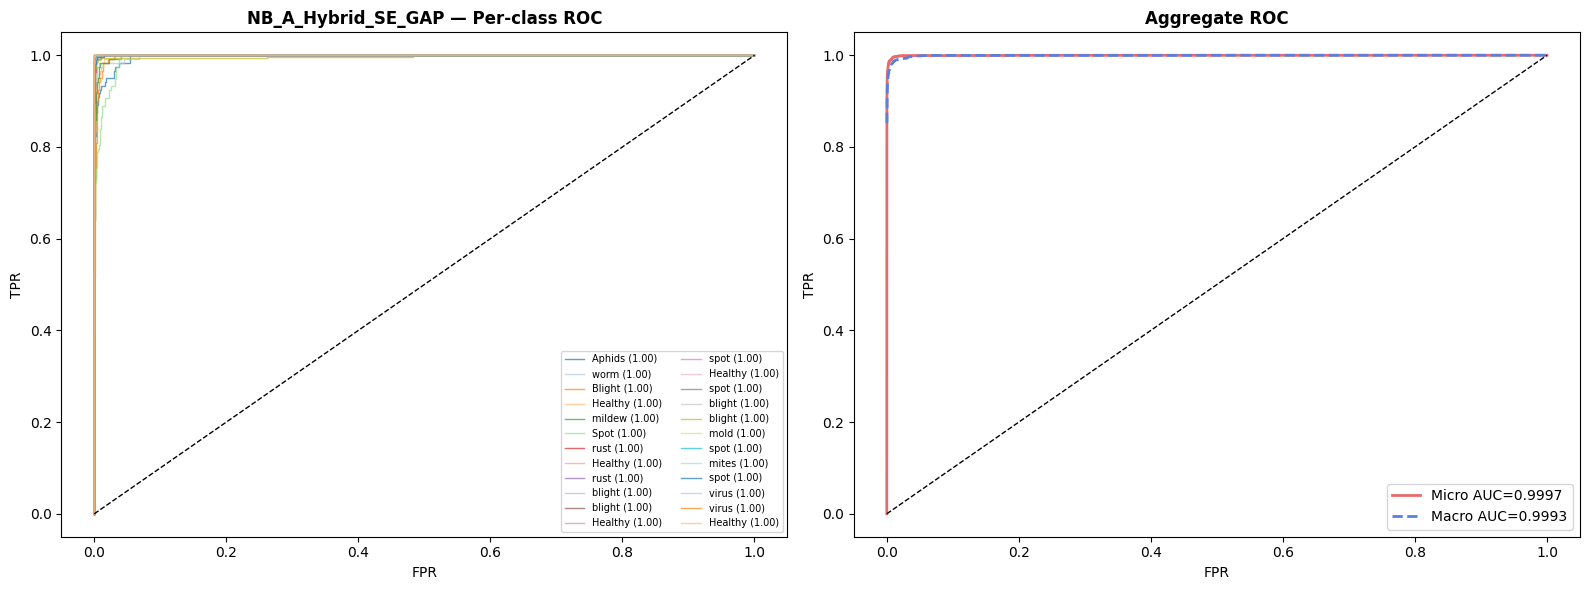

Micro AUC=0.9997  Macro AUC=0.9993


In [19]:
# ROC curves
y_bin=label_binarize(y_true,classes=list(range(NUM_CLASSES)))
fpr_d,tpr_d,roc_auc_d={},{},{}
for i in range(NUM_CLASSES):
    fpr_d[i],tpr_d[i],_=roc_curve(y_bin[:,i],y_prob[:,i]); roc_auc_d[i]=auc(fpr_d[i],tpr_d[i])
fpr_d['micro'],tpr_d['micro'],_=roc_curve(y_bin.ravel(),y_prob.ravel()); roc_auc_d['micro']=auc(fpr_d['micro'],tpr_d['micro'])
all_fpr=np.unique(np.concatenate([fpr_d[i] for i in range(NUM_CLASSES)]))
mean_tpr=np.zeros_like(all_fpr)
for i in range(NUM_CLASSES): mean_tpr+=np.interp(all_fpr,fpr_d[i],tpr_d[i])
mean_tpr/=NUM_CLASSES
fpr_d['macro'],tpr_d['macro']=all_fpr,mean_tpr; roc_auc_d['macro']=auc(all_fpr,mean_tpr)

fig,axes=plt.subplots(1,2,figsize=(16,6))
colors=cycle(plt.cm.tab20.colors)
for i,color in zip(range(NUM_CLASSES),colors):
    axes[0].plot(fpr_d[i],tpr_d[i],color=color,lw=1,alpha=0.7,
                 label=f'{TARGET_CLASSES[i].split("_")[-1]} ({roc_auc_d[i]:.2f})')
axes[0].plot([0,1],[0,1],'k--',lw=1); axes[0].set_title(f'{NOTEBOOK_ID} — Per-class ROC',fontweight='bold')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].legend(loc='lower right',fontsize=7,ncol=2)
axes[1].plot(fpr_d['micro'],tpr_d['micro'],color='#E86B6B',lw=2,label=f'Micro AUC={roc_auc_d["micro"]:.4f}')
axes[1].plot(fpr_d['macro'],tpr_d['macro'],color='#5B7FDE',lw=2,ls='--',label=f'Macro AUC={roc_auc_d["macro"]:.4f}')
axes[1].plot([0,1],[0,1],'k--',lw=1); axes[1].set_title('Aggregate ROC',fontweight='bold')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].legend(fontsize=10)
plt.tight_layout(); plt.savefig(os.path.join(LOG_DIR,'roc_curves.png'),dpi=120,bbox_inches='tight'); plt.show()

np.save(os.path.join(LOG_DIR,'y_prob.npy'),y_prob); np.save(os.path.join(LOG_DIR,'y_true.npy'),y_true)
roc_df=pd.DataFrame({'class':list(range(NUM_CLASSES))+['micro','macro'],
                     'auc':[roc_auc_d[i] for i in range(NUM_CLASSES)]+[roc_auc_d['micro'],roc_auc_d['macro']]})
roc_df.to_csv(os.path.join(LOG_DIR,'roc_auc.csv'),index=False)
print(f'Micro AUC={roc_auc_d["micro"]:.4f}  Macro AUC={roc_auc_d["macro"]:.4f}')


In [20]:
model.save(os.path.join(BASE_DIR,'model.h5'))
with open(os.path.join(BASE_DIR,'class_mapping.json'),'w') as f:
    json.dump({'idx_to_class':IDX_TO_CLASS,'class_to_idx':CLASS_TO_IDX,'notebook':NOTEBOOK_ID},f,indent=2)
print(f'FINAL — {NOTEBOOK_ID}')
print(f'  Accuracy : {acc:.4f}  F1 : {f1:.4f}  Macro AUC : {roc_auc_d["macro"]:.4f}')
print(f'  Params   : {model.count_params():,}')
print(f'  vs NB4 Std-Inception: 0.9533 (270K params)')
print(f'  vs NB5 ResNet:        0.9604 (741K params)')


FINAL — NB_A_Hybrid_SE_GAP
  Accuracy : 0.9671  F1 : 0.9671  Macro AUC : 0.9993
  Params   : 949,782
  vs NB4 Std-Inception: 0.9533 (270K params)
  vs NB5 ResNet:        0.9604 (741K params)


In [21]:
import shutil, os

src = '/root/plant_project'
dst = '/kaggle/working/plant_project'

if os.path.exists(dst):
    shutil.rmtree(dst)          # copytree requires dst to not already exist

shutil.copytree(src, dst)
print("Directory copied to /kaggle/working/ — now visible in Output tab")


shutil.make_archive('/kaggle/working/plant_project/NB_A_Hybrid_SE_GAP/logs', 'zip', '/kaggle/working/plant_project/NB_A_Hybrid_SE_GAP/logs')
print("Zipped!")

Directory copied to /kaggle/working/ — now visible in Output tab
Zipped!
